<h1><center>Modelling and Engineering of Nanoscale Materials <br>
    Exercises session 2: Molecular interactions - 2025</center></h1>
<center>massimo.bocus@ugent.be,  arnout.maet@ugent.be, thomas.nicholas@ugent.be</center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ase.io import read, write
from ase.units import *
from pyiron import Project, ase_to_pyiron
import pyiron_gpl

%matplotlib inline

<div class="alert alert-block alert-warning">
<b>Educational Objectives</b> <br> 
1. Understand the difference between the various chemical bonds <br>
2. Construct workflows with pyiron to make potential energy scans, making use of pyiron tables and filters
</div>

## Introduction

Normally everything we require for this lesson should already be configured and installed during last week's exercise lesson. If you did not succeed last week, check the previous notebook. 

While pyiron allows us to hide a lot of technical aspects of the underlying software packages, it is still necessary to become acquainted with some of the keywords that can be parsed through pyiron, related to the specific software. In this lesson we will start exploring the Gaussian plugin, and it functionalities. For that purpose, it could be interesting to check the Gaussian site on possible __[level of theories](http://gaussian.com/dft/)__  and __[basis sets](http://gaussian.com/basissets/)__ which will have to provided as input.

<div class="alert alert-block alert-info">
<b>Tip - the ASE units</b> <br> 
    
During this lesson we will be converting between different units. Consult the `pyiron_units.pdf` document to see which units are being outputted, and how you can convert to the required unit using ASE.

Load a new project for this week and continue below.

In [3]:
# Create a new project entitled session2
pr = Project('session2')

<div class="alert alert-block alert-info">
<b>Tip - subprojects</b> <br>
    
Create a subproject for every exercise, to keep your jobs well organized.

## Exercise 1: Water molecule

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Load the water molecule calculation from last week <br>
    2. Study the geometry and dipole moment of the molecule  <br>
    3. Calculate the dissociation energy
</div>

In [4]:
ex1 = pr.create_group('ex1')

Load the optimisation job from last week and answer the questions below using its output.

In [5]:
pr_session1 = Project('session1')
job_h2o_opt = pr_session1.load('h2o_opt')
optimized_structure_h2o = job_h2o_opt.get_structure()

In [6]:
# Create a pyiron Gaussian job with the appropriate name
job_h2o_sp = pr.create_job(ex1.job_type.Gaussian, 'optimized_h2o_sp', delete_existing_job=True)

# Assign structure
job_h2o_sp.structure = optimized_structure_h2o
    
# Assign basic Gaussian inputs
job_h2o_sp.input['jobtype'] = 'sp'
job_h2o_sp.input['lot'] = 'MP2'
job_h2o_sp.input['basis_set'] = '6-31+G(d)'
job_h2o_sp.input['charge'] = 0
job_h2o_sp.input['spin_mult'] = 1

# Server settings
job_h2o_sp.server.queue = 'donphan'
job_h2o_sp.server.cores = 4
job_h2o_sp.server.run_time = 5 * 60

job_h2o_sp.run()

The job optimized_h2o_sp was saved and received the ID: 797
Queue system id:  202559484


<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li>  Look up the dipole moment vector in the output (<tt>job.content['output/structure/dipole']</tt>) and compare its magnitude with literature ($d$ = 1.85 D = 0.728 a.u.) </li>
<br>
<li> Look up the energy of the molecule in the output (<tt>job.output.energy_tot</tt>). What is the physical meaning of this energy? </li>
<br>
<li> Derive the dissociation energy of water in kJ/mol. Does this correspond to tabulated values? ($\Delta E$ = 0.375 au = 985 kJ/mol) </li>
</ol>
</div>

<div class="alert alert-block alert-info">
<b>Hint</b> <br>
    
The dissociation energy is defined as: ${\normalsize \Delta E = E_{molecule} - \sum_i n_i E_{atom_i}}$, where $n_i$ is the numerical proportion of atom i. <br> Pay attention to the spin states of the isolated atoms! You can set the spin multiplicity by altering <tt>job.input['spin_mult']</tt>.

<div class="alert alert-block alert-info">
<b>Hint</b> <br>
    
What level of theory (LOT) and basis set should you choose to calculate the atomic energies? What job type should you choose?

### Question 1

In [12]:
dipole_moment_vector = job_h2o_opt['output/structure/dipole']
dipole_moment_magnitude = np.linalg.norm(dipole_moment_vector)

print(f"Dipole Moment Vector (a.u.): {dipole_moment_vector}")
print(f"Dipole Moment Vector Magnitude (a.u.): {dipole_moment_magnitude:.6f}")

Dipole Moment Vector (a.u.): [ 1.74355216e-16 -6.88210020e-16 -9.15532380e-01]
Dipole Moment Vector Magnitude (a.u.): 0.915532


### Question 2

In [14]:
total_energy_eV = job_h2o_sp.output.energy_tot[-1]
total_energy_hartree = job_h2o_sp.output.energy_tot[-1] / Hartree

print(f"Energy (eV): {total_energy_eV}")
print(f"Energy (Hartree): {total_energy_hartree}")

Energy (eV): -2073.7736488376454
Energy (Hartree): -76.2097765612021


### Question 3

<div class="alert alert-block alert-info">
<b>Tip - job function</b> <br>
    
We recommend to create (or copy) a job function for Gaussian, since multiple calculations will have to be performed which are similar in some way. Think of a signature for your function that would accommodate your current needs, with some possible extensions. An example of such a signature is provided below. This signature requires you to specify a project (to keep the jobs grouped), the name, structure, level of theory, basis set, charge and multiplicity, while allowing you to specify the specific job resources.

<div class="alert alert-block alert-danger">
<b>Warning:</b> <br>
    The job names are not allowed to start with a number or contain special characters altogether (underscore is allowed). Use descriptive strings! You could come up with a job function that automatically alters the job name to accommodate these limitations.
</div>

In [15]:
# A general Gaussian job function, this is easy to use within, for example, for-loops
def g16_job(pr, name, jobtype, structure, lot, basis_set, charge=0, multiplicity=1, settings={}, cluster='donphan', cores=4, run_time=5*60):
    
    # Create a pyiron Gaussian job with the appropriate name
    job = pr.create_job(pr.job_type.Gaussian, name, delete_existing_job=True)

    # Assign structure
    job.structure = structure
    
    # Assign basic Gaussian inputs
    job.input['jobtype'] = jobtype
    job.input['lot'] = lot
    job.input['basis_set'] = basis_set
    job.input['charge'] = charge
    job.input['spin_mult'] = multiplicity

    # Server settings
    job.server.queue = cluster
    job.server.cores = cores
    job.server.run_time = run_time
    
    job.run()

#### Intermezzo - datamining

<b>Basic Datamining</b> <br>
    
When the number of jobs within a project grows, filtering them and collecting some common output becomes cumbersome. One way to do this would be to iterate over all the jobs within a project, using `pr.iter_jobs()` or a list of jobs you made yourself, and using an `if` statement to filter out the correct ones <i>e.g.</i>:
    
```python
E = []
for job in pr.iter_jobs():
    if 'sp' in job.job_name: # include jobs that have 'sp' in their name
        E.append(job.content['output/generic/energy_tot'])   
```

or using list comprehension:

```python
E = np.array([[job.content['output/generic/energy_tot']] for job in pr.iter_jobs() if 'sp' in job.job_name])
```
    
To make things go faster, you can add the flag `convert_to_object=False` to the `iter_jobs` function. However, no job object is created when using this flag, such that you can not use any attribute or function of the job, and only the `job['output']` is accessible. You can also use these list comprehensions to easily apply a certain function on all your (filtered) jobs:
    
```python
jobs = [job for job in pr.iter_jobs() if 'identifier' in job.job_name]
plot_some_quantity(jobs)

```
    

<b>Advanced Datamining</b> <br> 
        
Aside from the approaches described above, there is an internal pyiron functionality which uses the `job_table` to filter your jobs instead of looping through every job. This approach is referred to as a pyiron table, which returns a Pandas dataframe based on the filter criteria you provide and the output properties you request. Again a distinction can be made between an explicit conversion to job objects and only using the `job['output']` for an additional speed-up. Taking again the example of an energy filter, we can split the pyiron table functionality up into two parts:
    
<ol type='a'>
<li> Defining the filters and required properties </li>
</ol>    
    

```python
# Filter function - explicit job object (slow)
def job_filter(job):
    return (job.status == 'finished') & ('sp' in job.job_name)

# Filter function - only use job_table properties (fast)
def db_filter(job_table):
    return (job_table.status == "finished") & (job_table.job.str.contains('sp', regex=False)) # difficult to extract job_name

# Property function
def get_e(job):
    return job.content['output/generic/energy_tot']
    
```
    
<ol type='a', start=2>
<li> Execute pyiron table job </li>
</ol>    
    
    
```python
# Create table
table = pr.create_table("table", delete_existing_job=True)

# Introduce filters, you can specify neither (if all jobs need to be extracted), one of them, or both (if you need both table and job properties)
#table.db_filter_function = db_filter # job_table filter
table.filter_function = job_filter # job object filter (both do exactly the same in our test case)

# If you need job properties aside from the output (slow!)
#table.convert_to_object = True        
    
# Introduce property function
table.add["E"] = get_e

# Run it
table.run()

# Get the dataframe
df = table.get_dataframe()
```
    
Finally, the dataframe can be filtered based on its column values, <i>e.g.</i>:
    
```python
data = df[df.lot=='HF']
energy = data.E
```    

As default it will order the values according to their job_id. However, you can always sort the dataframe according to a certain column:

    
```python
data = df[df.lot=='HF'].sort_values(by=['num_basis_functions'])
energy = data.E
```

If you want to access the input parameters, such as charge and spin multiplicity, you need to enable the convert_to_object:
    
```python
table.convert_to_object = True  # required for input attribute of job object 

def get_spin(job):
    return job.input['spin_mult']

def get_charge(job):
    return job.input['charge']
```

<div class="alert alert-block alert-info">
<b>Putting everything together</b> <br>
By combining a well-constructed function to submit Gaussian jobs and the datamining tips discussed above, you should be able to compute the formation energy of water with ease!
Projects have an easy way of generating simple atomistic structures (e.g., an isolated atom), you might want to have a look at the signature of 
    
    pr.create.structure.atoms

In [16]:
hydrogen = ex1.create.structure.atoms(symbols = 'H')
oxygen = ex1.create.structure.atoms(symbols = 'O')

g16_job(ex1, 'hydrogen_sp', 'sp', hydrogen, 'MP2', '6-31+G(d)', charge=0, multiplicity=2, cluster = 'donphan')
g16_job(ex1, 'oxygen_sp', 'sp', oxygen, 'MP2', '6-31+G(d)', charge=0, multiplicity=3, cluster = 'donphan')

The job hydrogen_sp was saved and received the ID: 798
Queue system id:  202559494
The job oxygen_sp was saved and received the ID: 799
Queue system id:  202559504


In [27]:
ex1.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,781,finished,H2O,optimized_h2o_sp,/optimized_h2o_sp,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex1/,2025-12-25 13:12:36.701077,2025-12-25 13:12:51.621904,14.0,pyiron@node4001.donphan.os#2#donphan,Gaussian,0.1,None,None
1,798,finished,H,hydrogen_sp,/hydrogen_sp,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex1/,2025-12-25 15:13:32.437099,2025-12-25 15:13:46.651247,14.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
2,799,finished,O,oxygen_sp,/oxygen_sp,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex1/,2025-12-25 15:13:32.478712,2025-12-25 15:13:46.555339,14.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None


In [21]:
total_energy_isolated_atoms_h2o = 0

for job in ex1.iter_jobs():
    if 'hydrogen_sp' in job.job_name:
        total_energy_isolated_atoms_h2o += 2 * job.content['output/generic/energy_tot'][-1]

    if 'oxygen_sp' in job.job_name:
        total_energy_isolated_atoms_h2o += job.content['output/generic/energy_tot'][-1]

dissociation_energy_h2o_eV = np.abs(total_energy_eV - total_energy_isolated_atoms_h2o)

print(f"Dissociation Energy (eV): {dissociation_energy_h2o_eV}")
print(f"Dissociation Energy (kJ/mol): {dissociation_energy_h2o_eV / (kJ / mol):.2f}")

  0%|          | 0/3 [00:00<?, ?it/s]

Dissociation Energy (eV): 8.925871397810624
Dissociation Energy (kJ/mol): 861.22


## Exercise 2: The hydrogen bond

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Construct a water dimer <br>
    2. Optimise its geometry  <br>
    3. Perform a rigid scan of the distance between the two molecules  <br>
</div>

As we saw last week, there are multiple ways to construct structures compatible with pyiron. From now on, you may choose the approach that you think is most suited depending on the situation. Using an interactive builder, like GaussView, can be very convenient if you want to create large and complex 3-dimensional structures. Using the ASE geometry manipulation tools we introduced in the previous notebook can be very convenient if you want to create simple structures or modify them in an automated fashion.

<b>Build a water dimer (either within the notebook or using GaussView) and answer the questions below.</b>

<div class="alert alert-block alert-info">
<b>Tip - combing structure objects</b> <br>
    
Merging two structures is relatively easy in pyiron:
    
```python
water1 = water.copy() # create a copy of the structure object called water
water2 = water.copy()
dimer = water1 + water2 # now the two molecules are on top of each other!
dimer.set_distance(...) # check the function signature and the ASE website
```    

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li>  Optimize the dimer <b>with the same level of theory used for the water molecule in session1</b>. What is the optimal hydrogen bond length? Compare it with the typical hydrogen bond in water (1.97 Å) and the typical covalent O-H bond (0.96 Å). </li>
<br>
<li> Compute the strength of the hydrogen bond by deriving the interaction energy between the two water molecules and compare with the typical strength of H-bonds in literature (5-30 kJ/mol). </li>
<br>
<li> Obtain the dissociation profile of the water dimer for O-H distances between 1.0 and 10 Å. Compare the long-distance limit with the interaction energy you obtained in question 2. </li>
</ol>
</div>

<div class="alert alert-block alert-info">
<b>Tip - Computing interaction energies</b> <br>
    
Most physico-chemical transformations (phase transitions, chemical reactions...) are characterized by a starting set of atoms (the reactants) that is converted in a certain product. We can write the process with the chemical equation:

$r_1R_1 + r_2R_2 + ... \rightarrow p_1P_1 + p_2P_2 + ...$

Where $r_1$ mol of $R_1$ react with $r_2$ mol of $R_2$ and so on to give $p_1$ mol of $P_1$, $p_2$ mol of $P_2$ and so on. The energy gained or lost during the process is obviously the simple difference between the overall energy of the products and the overall energy of the reactants:

$\Delta E_\mathrm{reaction} = \sum_i p_i E(P_i) - \sum_j r_j E(R_j)$

In this initial example, the process that you have to evaluate to determine the strength of an hydrogen bond is the simply: $2H_2O \rightarrow H_2O\cdot\cdot\cdot H_2O$ (i.e. two $H_2O$ molecules infinitely far apart come together to form the dimer).

In [55]:
ex2 = pr.create_group('ex2')

### Question 1

In [56]:
# Retrieve optimized water monomer structure
water_molecule = job_h2o_opt.get_structure()

# Instantiate two independent monomer copies
water_molecule_1 = water_molecule.copy()
water_molecule_2 = water_molecule.copy()

# Reorient second monomer to approximate dimer configuration
water_molecule_2.euler_rotate(90.0, 180.0, 0.0, center=(0.0, 0.0, 0.0))

# Apply translational displacement of 3.0 Å along x-axis
water_molecule_2.positions += [3.0, 0.0, 0.0]

# Concatenate monomers into a single water dimer
water_dimer = water_molecule_1 + water_molecule_2

# Serialize to XYZ format and reload as pyiron object
write("water_dimer.xyz", water_dimer)
water_dimer = ase_to_pyiron(read("water_dimer.xyz"))

# Plot 3D molecular structure
water_dimer.plot3d(spacefill=False)

NGLWidget()

In [57]:
g16_job(ex2, 'water_dimer_opt', 'opt', water_dimer, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')

The job water_dimer_opt was saved and received the ID: 800
Queue system id:  202561114


In [60]:
ex2.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,800,finished,H4O2,water_dimer_opt,/water_dimer_opt,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:34:47.928431,2025-12-25 17:36:32.373973,104.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None


In [61]:
job_water_dimer_opt = pr.load('water_dimer_opt')

water_dimer_opt = job_water_dimer_opt.get_structure()
water_dimer_opt.plot3d(spacefill=False)

NGLWidget()

In [62]:
hydrogen_bond_distance = water_dimer_opt.get_distance(0,5)

print(f"Hydrogen Bond Distance (Å): {hydrogen_bond_distance}")

Hydrogen Bond Distance (Å): 1.9304960840183134


### Question 2

In [63]:
g16_job(ex2, 'water_dimer_sp', 'sp', water_dimer_opt, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')

The job water_dimer_sp was saved and received the ID: 801
Queue system id:  202561134


In [68]:
job_water_dimer_sp = ex2.load('water_dimer_sp') 

In [69]:
energy_single_water_molecule = total_energy_eV
energy_water_molecule_dimer = job_water_dimer_sp.output.energy_tot[-1]

interaction_energy_water_molecules_eV = energy_water_molecule_dimer - 2 * energy_single_water_molecule

print(f"Strength of Hydrogen Bond (eV): {interaction_energy_water_molecules_eV}")
print(f"Strength of Hydrogen Bond (kJ/mol): {interaction_energy_water_molecules_eV / (kJ / mol)}")

Strength of Hydrogen Bond (eV): -0.30392389647204254
Strength of Hydrogen Bond (kJ/mol): -29.324198322051117


### Question 3
Now that we have optimized the dimer, we can construct its dissociation curve by looking at the energy as a function of the distance between the two water molecules. Two main options are available here:
<ol type='a'>
<li> <b>Rigid scan:</b>perform a series of single point jobs (using a for loop) to scan the different distances with a custom function that modifies the structure. </li>
<li> <b>Relaxed scan:</b> this is a feature of Gaussian16, where at each point the system is relaxed while freezing the internal coordinate that is being scanned. </li>
</ol>
While the latter is cleaner, with a minimal number of files created, the former can be performed in parallel since all jobs are submitted separately. <b>For this session, we will rely on rigid scans.</b> We will discuss relax scans more in details in the following session.

<div class="alert alert-block alert-info">
<b>Tip - performing a rigid scan</b> <br>
To perform a rigid scan, you need a function that can adapt the internal coordinate (bond, angle, dihedral) of your molecule to the desired value.

```python
def adapt_distance(structure, distance):
    adapted_structure = structure.copy()
    adapted_structure.set_distance(...) # use the appropriate settings
    return adapted_structure
```

With such a function, you can then run a rigid scan with a for loop:

```python
distances = np.linspace(0.5, 3.0, 10)
for i, distance in enumerate(distances):
    adapted_structure = adapt_structure(structure, distance)
    job = pr.create_job(pr.job_type.Gaussian, f"scan_{i}", delete_existing_job=True)
    job.input['jobtype'] = "sp"
    job.structure = adapted_structure
    # Add other options
```

In [70]:
def adapt_distance(structure, distance):
    adapted_structure = structure.copy()
    adapted_structure.set_distance(0, 5, distance, mask = [0,0,0,1,1,1])
    return adapted_structure

In [71]:
distances = np.linspace(1.0, 10.0, 30)
for i, distance in enumerate(distances):
    adapted_structure = adapt_distance(water_dimer_opt, distance)
    job = pr.create_job(pr.job_type.Gaussian, f"scan_{i}", delete_existing_job=True)
    job.input['jobtype'] = "sp"
    g16_job(ex2, f"scan_water_dimer_{i}", 'sp', adapted_structure, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')

The job scan_water_dimer_0 was saved and received the ID: 802
Queue system id:  202561144
The job scan_water_dimer_1 was saved and received the ID: 803
Queue system id:  202561154
The job scan_water_dimer_2 was saved and received the ID: 804
Queue system id:  202561164
The job scan_water_dimer_3 was saved and received the ID: 805
Queue system id:  202561174
The job scan_water_dimer_4 was saved and received the ID: 806
Queue system id:  202561194
The job scan_water_dimer_5 was saved and received the ID: 807
Queue system id:  202561204
The job scan_water_dimer_6 was saved and received the ID: 808
Queue system id:  202561214
The job scan_water_dimer_7 was saved and received the ID: 809
Queue system id:  202561224
The job scan_water_dimer_8 was saved and received the ID: 810
Queue system id:  202561234
The job scan_water_dimer_9 was saved and received the ID: 811
Queue system id:  202561244
The job scan_water_dimer_10 was saved and received the ID: 812
Queue system id:  202561254
The job s

In [87]:
ex2.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,800,finished,H4O2,water_dimer_opt,/water_dimer_opt,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:34:47.928431,2025-12-25 17:36:32.373973,104.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
1,801,finished,H4O2,water_dimer_sp,/water_dimer_sp,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:37:47.910323,2025-12-25 17:38:01.563372,13.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
2,802,finished,H4O2,scan_water_dimer_0,/scan_water_dimer_0,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:40:47.176901,2025-12-25 17:41:02.132233,14.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
3,803,finished,H4O2,scan_water_dimer_1,/scan_water_dimer_1,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:40:47.192651,2025-12-25 17:41:02.203217,15.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
4,804,finished,H4O2,scan_water_dimer_2,/scan_water_dimer_2,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:41:53.149997,2025-12-25 17:42:06.471568,13.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
5,805,finished,H4O2,scan_water_dimer_3,/scan_water_dimer_3,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:41:53.176201,2025-12-25 17:42:06.515885,13.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
6,806,finished,H4O2,scan_water_dimer_4,/scan_water_dimer_4,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:43:02.948753,2025-12-25 17:43:17.657724,14.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
7,807,finished,H4O2,scan_water_dimer_5,/scan_water_dimer_5,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:43:03.067045,2025-12-25 17:43:17.694954,14.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
8,808,finished,H4O2,scan_water_dimer_6,/scan_water_dimer_6,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:44:04.804843,2025-12-25 17:44:20.916597,16.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
9,809,finished,H4O2,scan_water_dimer_7,/scan_water_dimer_7,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex2/,2025-12-25 17:44:04.783378,2025-12-25 17:44:20.863044,16.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None


In [88]:
total_energies_water_dimer = np.zeros(len(distances)) 

for job in ex2.iter_jobs():
    
    if 'scan_water_dimer_' in job.job_name:
        i = int(job.job_name.split('_')[-1])
        total_energies_water_dimer[i] = job.output.energy_tot[-1]

  0%|          | 0/32 [00:00<?, ?it/s]

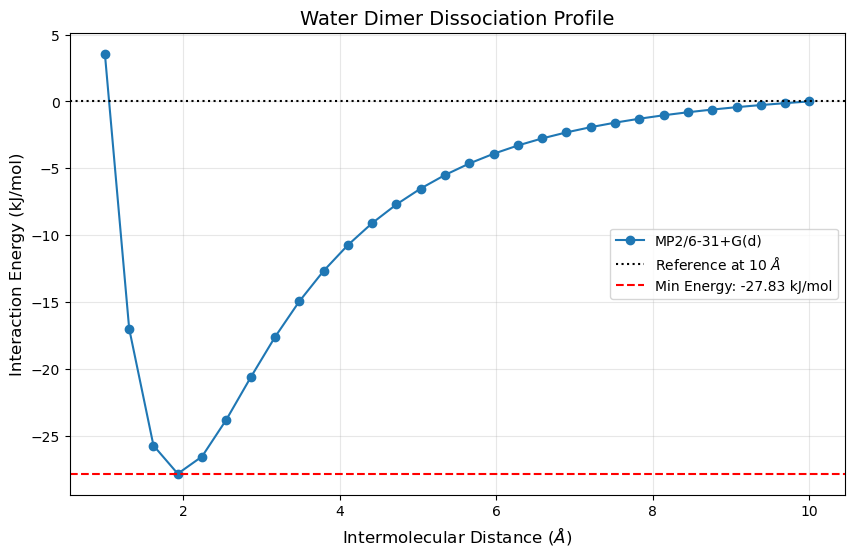

In [89]:
# Set Reference Energy (Energy at 10 Å, which is the last value)
E_reference = total_energies_water_dimer[-1]

# Calculate Interaction Energy (Relative to 10 Å) and convert to kJ/mol
interaction_energies_kJmol = (total_energies_water_dimer - E_reference) / (kJ / mol)

# Find the minimum energy for the plot line
min_energy = np.min(interaction_energies_kJmol)
min_distance_index = np.argmin(interaction_energies_kJmol)
min_distance = distances[min_distance_index]

# Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(distances, interaction_energies_kJmol, 'o-', label='MP2/6-31+G(d)')

# Add Dotted Line at 0 (Reference)
plt.axhline(0, color='black', linestyle=':', linewidth=1.5, label='Reference at 10 $\AA$')

# Add Dashed Line at Minimum
plt.axhline(min_energy, color='red', linestyle='--', linewidth=1.5, label=f'Min Energy: {min_energy:.2f} kJ/mol')

# Labels and Styling
plt.xlabel('Intermolecular Distance ($\AA$)', fontsize=12)
plt.ylabel('Interaction Energy (kJ/mol)', fontsize=12)
plt.title('Water Dimer Dissociation Profile', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

## Exercise 3: The relative strength of inter- and intramolecular interactions

<div class="alert alert-block alert-warning">
<b>In short:</b> <br>
    1. Construct a set of molecules and dimers that exemplify some inter- and intramolecular interactions (H$_2$, He$_2$, NaCl, and a CO dimer as example of covalent, van der Waals, ionic, and dipole-dipole interaction). <br>
    2. Optimise their geometry.<br>
    3. Perform a rigid scan of the bond length (for diatomic species) or intermolecular distance (for dimers).  <br>
    4. Rank inter- and intramolecular interactions based on their strength.  <br>
</div>

Similar to the previous exercise,  we want to optimise a molecular system, for which we already have defined a function. Moreover, you should know by now how to create a diatomic system and molecular dimers. As we will require many diatomic systems in the following exercises, it would be convenient to create a function for that as well. Use the `pr.create.structure.atoms` function, to generate the structure object. Remember that you can always consult the signature of a function by executing a code block with the function, followed by `??`. **Again use the same level of theory and basis set as the previous question.**

<div class="alert alert-block alert-info">
<b>Tip - create_atoms</b> <br>
    
When creating cluster structures with `create_atoms` remember to set `pbc=False` as we are creating a molecule.

In [90]:
ex3 = pr.create_group('ex3')

In [94]:
def construct_diatomic_system(pr, symbol_element_1, symbol_element_2, bond_length=2.0, box_size=10.0):
    diatomic_system = pr.create.structure.atoms(
    elements=[symbol_element_1, symbol_element_2], 
    positions=[[0, 0, 0], [0, 0, bond_length]], 
    cell=[box_size, box_size, box_size], 
    pbc=False)
    return diatomic_system

<div class="alert alert-block alert-success">
<b>Answer the following questions:</b> <br>   
<ol type='a'>
<li> Measure the equilibrium bond length (for diatomic species) or the equilibrium intermolecular distance (for dimers). How does it change depending on the interaction type? </li>
<br>
<li> Compute the dissociation energy for each species considering the isolated atomic components (for diatomic species) or the isolated molecule (for dimers). </li>
<br>
<li> How well can a simple electrostatic interaction between two opposite charges and two aligned dipoles reproduce the interaction energies of NaCl and the CO dimer? Comment. </li>
<br> 
<li> Obtain the dissociation profile of the various species from a rigid scan of the bond length (for diatomic species) or the intermolecular distance (for dimers). You may select an appropriate distance range. Include the dissociation profile you have obtained for water and discuss the relative strength of intra- and intermolecular interactions. </li>
<br>
<li> Bonus question: you may see something strange going on with the dissociation profile of H$_2$. The culprit is the level of theory we are using. Try again using a CCSD/cc-pVDZ level of theory. Do the results look better? </li>
</ol>
</div>

### Question 1

In [95]:
structure_h2 = construct_diatomic_system(ex3, 'H', 'H')
structure_he2 = construct_diatomic_system(ex3, 'He', 'He')
structure_nacl = construct_diatomic_system(ex3, 'Na', 'Cl')

In [136]:
co_monomer = ex3.create.structure.atoms(
    elements=['C', 'O'], 
    positions=[[0, 0, 0], [0, 0, 1.13]], 
    cell=[10, 10, 10], 
    pbc=False
)

co_1 = co_monomer.copy()
co_2 = co_monomer.copy()
co_2.euler_rotate(0.0, 170.0, 5.0, center=(0.0, 0.0, 0.0))
co_2.positions += [2.0, 0.1, 1.13]

structure_co_dimer = co_1 + co_2

In [137]:
structure_co_dimer.plot3d()

NGLWidget()

In [121]:
g16_job(ex3, 'h2_opt', 'opt', structure_h2, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')
g16_job(ex3, 'he2_opt', 'opt', structure_he2, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')
g16_job(ex3, 'nacl_opt', 'opt', structure_nacl, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')
g16_job(ex3, 'co_dimer_opt', 'opt', structure_co_dimer, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')

The job h2_opt was saved and received the ID: 836
Queue system id:  202562294
The job he2_opt was saved and received the ID: 837
Queue system id:  202562304
The job nacl_opt was saved and received the ID: 838
Queue system id:  202562314
The job co_dimer_opt was saved and received the ID: 839
Queue system id:  202562324


In [138]:
g16_job(ex3, 'co_dimer_opt', 'opt', structure_co_dimer, 'MP2', '6-31+G(d)', charge=0, multiplicity=1, cluster = 'donphan')

The job co_dimer_opt was saved and received the ID: 839
Queue system id:  202562344


In [144]:
ex3.job_table()

,id,status,chemicalformula,job,subjob,projectpath,project,timestart,timestop,totalcputime,computer,hamilton,hamversion,parentid,masterid
0,836,finished,H2,h2_opt,/h2_opt,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex3/,2025-12-25 20:14:21.276672,2025-12-25 20:14:57.337458,36.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
1,837,finished,He2,he2_opt,/he2_opt,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex3/,2025-12-25 20:14:49.760861,2025-12-25 20:15:25.523270,35.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
2,838,finished,ClNa,nacl_opt,/nacl_opt,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex3/,2025-12-25 20:16:25.047771,2025-12-25 20:17:16.393964,51.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None
3,839,aborted,C2O2,co_dimer_opt,/co_dimer_opt,None,/kyukon/data/gent/courses/2025/nanoscale_E006800/members/vsc48511/session2/ex3/,2025-12-25 20:24:58.344304,2025-12-25 20:28:18.010576,199.0,pyiron@node4001.donphan.os#4#donphan,Gaussian,0.1,None,None


In [126]:
job_h2_opt = ex3.load('h2_opt')
structure_h2_opt = job_h2_opt.get_structure()
print(f"Equilibrium Bond Length (Å): {structure_h2_opt.get_distance(0,1)}")

Equilibrium Bond Length (Å): 0.7372090986904299


In [127]:
job_he2_opt = ex3.load('he2_opt')
structure_he2_opt = job_he2_opt.get_structure()
print(f"Equilibrium Bond Length (Å): {structure_he2_opt.get_distance(0,1)}")

Equilibrium Bond Length (Å): 3.148784577111508


In [128]:
job_nacl_opt = ex3.load('nacl_opt')
structure_nacl_opt = job_nacl_opt.get_structure()
print(f"Equilibrium Bond Length (Å): {structure_nacl_opt.get_distance(0,1)}")

Equilibrium Bond Length (Å): 2.4040220473683753


In [ ]:
job_nacl_opt = ex3.load('nacl_opt')
structure_nacl_opt = job_nacl_opt.get_structure()
print(f"Equilibrium Bond Length (Å): {structure_nacl_opt.get_distance(0,1)}")

### Question 2

### Question 3

In [ ]:
# Add code here

### Question 4

In [ ]:
# Add code here

### Question 5

In [ ]:
# Add code here

## Exam info - sharing Gaussian jobs

With all the exercises above it should be clear how to perform basic Gaussian jobs using the pyiron package. However, during the exam it might be convenient to share data with your colleagues. Sharing data is not very straightforward, since each of you has their own database of job objects, tagged with their specific location on your drive. However, we can trick pyiron in thinking we performed the job manually and load it into the database. Below you will find a complete example on how Gaussian jobs can be shared, assuming you have the correct input parameters. 

In [ ]:
# Define job object
job = pr.create_job(pr.job_type.Gaussian, name) # you can choose a different name
job.structure = structure # this can also be shared, structures can be written to file using structure.write()

# Assign all the input variables of the original job
job.input[...] = ...


# Add the fchk and log file to as additional input
# the files have to be called input.fchk and input.log
job.restart_file_list.append(os.path.join(os.path.abspath(location_to_shared_files), 'input.fchk')) 
job.restart_file_list.append(os.path.join(os.path.abspath(location_to_shared_files), 'input.log'))
job.server.run_mode.manual = True
job.run()

In [ ]:
# Collect the job output and store it in the job object
job.status.collect = True
job.run()